# Setting up a latent function Gaussian Process for H(z)

In [1]:
# import set 
using Turing
using Distances
using LinearAlgebra
using LimberJack
using Interpolations
using GaussianProcess
using Plots
using QuadGK
using BlockDiagonals
using CSV
using DataFrames
using PrettyTables
import LimberJack.TkEisHu
using NumericalIntegration

### Collate data

In [2]:
# hz data
function data_hz()
    z = [
        0.07, 0.09, 0.12, 0.17, 0.179, 0.199, 0.2,
        0.27, 0.28, 0.352, 0.38, 0.3802, 0.4,
        0.4004, 0.4247, 0.44, 0.4497, 0.47, 0.4783,
        0.48, 0.51, 0.593, 0.6, 0.61, 0.68, 0.73,
        0.781, 0.875, 0.88, 0.9, 1.037, 1.3,
        1.363, 1.43, 1.53, 1.75, 1.965
    ]

    data = [
        69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9,
        77.0, 88.8, 83.0, 81.5, 83.0, 95.0, 77.0,
        87.1, 82.6, 92.8, 89.0, 80.9, 97.0, 90.4,
        104.0, 87.9, 97.3, 92.0, 97.3, 105.0,
        125.0, 90.0, 117.0, 154.0, 168.0, 160.0,
        177.0, 140.0, 202.0, 186.5
    ]

    err = [
        19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6,
        14.0, 36.6, 14.0, 1.9, 13.5, 17.0, 10.2,
        11.2, 7.8, 12.9, 23.0, 9.0, 62.0, 1.9,
        13.0, 6.1, 2.1, 8.0, 7.0, 12.0, 17.0,
        40.0, 23.0, 20.0, 17.0, 33.6, 18.0,
        14.0, 40.0, 50.4
    ]

    cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end

    return (
        data_name = "data_hz",
        z = z,
        data = data,
        err = err,
        cov = cov
    )
end

# fs8 data
function data_fs8()

z  = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]

data  = [0.37784, 0.515897, 0.48384, 0.422208, 0.37468, 0.435]

fs8_upper = [0.4723, 0.572693, 0.539136, 0.470586, 0.418064, 0.48]
fs8_lower = [0.28338, 0.449635, 0.428544, 0.378228, 0.343128, 0.39]
err_up = fs8_upper .- data
err_low = data .- fs8_lower
err = (fs8_upper .- fs8_lower) ./ 2

cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end
    
    return (data_name = "data_fs8", z = z, data = data, err = err, cov = cov)
end

data_fs8 (generic function with 1 method)

In [3]:
# fs8 data
function data_combtracer_fs8()

z  = [0.026]
data  = [0.412]
err = 0.018

cov = [err^2;;]

    return (data_name = "data_combtracer_fs8", z = z, data = data, err = err, cov = cov)
end

datatracerfs8 = data_combtracer_fs8();

In [4]:
# Load data
supernovae_raw = CSV.read("DES_Dovekie_HD.csv", DataFrame);
# Find indices that satisfy the condition
keep_idx = findall(supernovae_raw.MUERR .< 1);
# Filter the dataframe
supernovae = supernovae_raw[keep_idx, :];
# Load covariance matrix
supernovae_cov_df = CSV.read("STAT+SYS_dovekie.csv", DataFrame);
supernovae_cov = Matrix(supernovae_cov_df);
# Filter covariance matrix (rows AND columns)
sup_cov_filt = supernovae_cov[keep_idx, keep_idx];

function data_mu()

    z = supernovae[!,"zHD"][1:30:end]
    z_hel = supernovae[!,"zHEL"][1:30:end]
    data = supernovae[!,"MU"][1:30:end]

    cov = Symmetric(sup_cov_filt[1:30:end, 1:30:end])

    err = sqrt.(diag(cov))

    return (data_name = "data_mu", z = z, z_hel = z_hel, data = data, err = err, cov = cov)

end

datamu = data_mu();

In [5]:
function data_DESI()
    # DESI data
    z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
    z = repeat(z1, inner = 4)
    data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
    data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508] 
    data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
    data_m = [-0.031370, 0.027840, 0.046650, -0.024690, 0.059960, 0.064550]
    
    data = 
    [7.788174, 3.053800, 0.377174, -0.031370,    # BGS (z=0.30)
    12.514437, 1.637266, 0.513635, 0.027840, # LRG1 (z=0.51)
    15.675560, 1.165867, 0.483623, 0.046650,  # LRG2 (z=0.71)
    19.676985, 0.844996, 0.422164, -0.024690, # LRG3 (z=0.92)
    23.861806, 0.470709, 0.376715, 0.059960,  # ELG2 (z=1.32)
    25.708520, 0.426508, 0.434858, 0.064550]   # QSO (z=1.49)

    # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
    # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
    # Source: arXiv:2411.12021 Appendix A
    C_total = zeros(24, 24);

    # BGS z=0.30
    C_total[1:4, 1:4] = [1314.664401  -142.669742   109.427163  -217.509715;
                -142.669742   829.170940  -158.101737   -61.084426;
                 109.427163  -158.101737    88.510877    -2.272457;
                -217.509715   -61.084426    -2.272457   279.702360] .* 1e-4

    # LRG1, zeff = 0.51
    C_total[5:8, 5:8] = [541.309833   48.425593    -4.652853   -37.707751;
                        48.425593   97.249820   -34.923265   -14.418597;
                        -4.652853  -34.923265    41.295470    15.405508;
                        -37.707751  -14.418597    15.405508    48.918910] .* 1e-4

    # LRG2, zeff = 0.71
    C_total[9:12, 9:12] = [762.457717   39.781004    -1.896006   -62.812849;
                            39.781004   36.344098   -17.341350    -8.333900;
                            -1.896006  -17.341350    28.119682     8.865225;
                        -62.812849   -8.333900     8.865225    47.624520] .* 1e-4

    # LRG3, zeff = 0.92
    C_total[13:16, 13:16] = [847.499793   26.038900     3.257324   -37.016091;
                            26.038900   16.251088   -10.044074    -3.698790;
                            3.257324  -10.044074    22.370314     6.467510;
                            -37.016091   -3.698790     6.467510    34.883220] .* 1e-4

    # ELG2, zeff = 1.32
    C_total[17:20, 17:20] = [2342.506886   26.159601    13.521001   -95.336060;
                                26.159601   10.309303    -6.654663    -5.183903;
                                13.521001   -6.654663    13.997473     9.109619;
                            -95.336060   -5.183903     9.109619    43.575710] .* 1e-4

    # QSO, zeff = 1.49
    C_total[21:24, 21:24] = [3013.788566   -2.205101    36.332110   -98.167826;
                                -2.205101    5.845806    -6.747133    -1.913326;
                                36.332110   -6.747133    19.785658     5.357546;
                            -98.167826   -1.913326     5.357546    26.266260] .* 1e-4

    
    cov = C_total
    
    err_arr = sqrt.(diag(cov))
    err_dvrd = err_arr[1:4:end]
    err_dhdm = err_arr[2:4:end]
    err_fss8 = err_arr[3:4:end]
    err_m = err_arr[4:4:end]

    return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fss8 = data_fss8, data_m = data_m, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fss8 = err_fss8, err_m = err_m, cov = cov)
end

data_DESI (generic function with 1 method)

In [6]:
datahz = data_hz();
dataDESI = data_DESI();

#### Putting data together

In [7]:
# errors
hz_err = datahz.err;
aiso_err = dataDESI.err_dvrd;
aap_err = dataDESI.err_dhdm;
fs8_err = datatracerfs8.err;
fss8_err = dataDESI.err_fss8;
m_err = dataDESI.err_m;
mu_err = datamu.err;


In [8]:
# outputs are arrays, not interpolators
# clight_hmpc is speed of light/10-5, 2997.92458 Mpc/h
function hz_from_ez(zarr, h0, ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())
    hz = ez_itp(zarr) .* (h0*100)
    return hz
end

function dm_from_ez(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    return chis
end
function fs8_from_ez(zarr, Ωm, σ8, h0, ez)

    T = typeof(Ωm)   # enforce parameter type

    ez_itp1 = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    E(a) = ez_itp1(one(T) ./ a .- one(T))
    Omega_m_a(a) = (Ωm / a^3) / E(a)^2

    function growth_system(a, y)
        D, y1 = y
        dD_da = y1 / (a^3 * E(a))
        dy1_da = (T(1.5)) * a * E(a) * Omega_m_a(a) * D
        return (dD_da, dy1_da)   # tuple is better than vector
    end

    function solve_growth_rk4(a_init::T, a_end::T, n_steps::Int) where T

        da = (a_end - a_init) / T(n_steps)

        a_vals = collect(range(a_init, a_end; length=n_steps+1))
        D_vals = zeros(T, n_steps + 1)
        y1_vals = zeros(T, n_steps + 1)

        D_vals[1] = a_init
        y1_vals[1] = a_init^3 * E(a_init) * one(T)

        for i in 1:n_steps
            a = a_vals[i]
            y = (D_vals[i], y1_vals[i])

            k1 = growth_system(a, y)
            k2 = growth_system(a + da/2, (y[1] + da*k1[1]/2, y[2] + da*k1[2]/2))
            k3 = growth_system(a + da/2, (y[1] + da*k2[1]/2, y[2] + da*k2[2]/2))
            k4 = growth_system(a + da,   (y[1] + da*k3[1],   y[2] + da*k3[2]))

            D_vals[i+1] =
                y[1] + da*(k1[1] + 2k2[1] + 2k3[1] + k4[1]) / T(6)

            y1_vals[i+1] =
                y[2] + da*(k1[2] + 2k2[2] + 2k3[2] + k4[2]) / T(6)
        end

        return a_vals, D_vals, y1_vals
    end

    # IMPORTANT: use parameter type here
    a_init = T(1e-3)
    a_end  = one(T)

    n_steps = 1000

    a_raw, D_raw, y1_raw = solve_growth_rk4(a_init, a_end, n_steps)

    D_today = D_raw[end]
    D_norm = D_raw ./ D_today

    f_raw = y1_raw ./ (a_raw.^2 .* E.(a_raw) .* D_raw)

    fs8_raw = f_raw .* (σ8 .* D_norm)

    a_plot = one(T) ./ (one(T) .+ zarr)

    fs8_itp = LinearInterpolation(a_raw, fs8_raw, extrapolation_bc=Line())
    Dz_itp = LinearInterpolation(a_raw, D_raw, extrapolation_bc=Line())
    fs8z = fs8_itp.(a_plot)
    Dz = Dz_itp.(a_plot) ./ D_today

    return Dz, fs8z
end
function _w_tophat(x::Real)
    x2 = x^2

    if x < 0.1
        w = 1. + x2*(-1.0/10.0 + x2*(1.0/280.0 +
            x2*(-1.0/15120.0 + x2*(1.0/1330560.0 +
            x2* (-1.0/172972800.0)))));
    else
        w = 3 * (sin(x)-x*cos(x))/(x2*x)
    end
    return w
end


"""
    sigma_s8_shapefit2(z, zarr, k, cosmo, s)

"""
function sigma_s8_shapefit2(
    z,
    zarr,
    ez,
    k,
    rd, rdrag_fid,
    cosmo        :: Cosmology
    )
    
    Dz_array = fs8_from_ez(zarr, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez)[1]
    growth_func = LinearInterpolation(zarr, Dz_array, extrapolation_bc=Line())
    
    Dz = growth_func(z)
    pk0 = @. exp(cosmo.PkLz0(log(k)))

    R = 8/cosmo.cpar.h
    
    s = rd /rdrag_fid

    x = k .* R .* s
    wk = _w_tophat.(x)
    integrand = @. pk0 * wk^2 * k^3
    sigma = integrate(log.(k), integrand, SimpsonEven())/(2*pi^2)
    return sigma .* Dz.^2

end

function fss8_from_ez(
    z,
    zarr,
    ez,
    k, rd, rdrag_fid,
    cosmo        :: Cosmology
    )

    fsigma_8 = fs8_from_ez(zarr, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez)[2];
    Dz_array = fs8_from_ez(zarr, cosmo.cpar.Ωm, cosmo.cpar.σ8, cosmo.cpar.h, ez)[1];
    sigma8_array = (cosmo.cpar.σ8 .* Dz_array) ./ Dz_array[1];
    growth_f = fsigma_8 ./ sigma8_array

    
    fsigma_s8 = growth_f .* sqrt.(sigma_s8_shapefit2(zarr, zarr, ez, k, rd, rdrag_fid, cosmo));
    return fsigma_s8
end
function dh(zarr, h0, ez)
    dhz = (LimberJack.CLIGHT_HMPC*100) ./ (hz_from_ez(zarr, h0, ez))
    return dhz
end

function dv(zarr, h0, ez)
    chis = similar(ez)
    ez_itp = LinearInterpolation(zarr, ez, extrapolation_bc=Line())

    for i in 1:length(zarr)
        zz = zarr[i]
        chis[i] = quadgk(z -> 1.0/ez_itp(z), 0.0, zz, rtol=1E-5)[1]
        chis[i] *= LimberJack.CLIGHT_HMPC / h0
    end
    
    dvs = similar(chis)
    for i in 1:length(zarr)
        zz = zarr[i]
        dvz_cbrt = zz * (LimberJack.CLIGHT_HMPC/(ez_itp(zz)*h0)) * (chis[i]^2)
        dvs[i] = abs(dvz_cbrt)^(1/3)
    end

    return dvs
end

function a_ap(zarr, h0, ez)
  numer = dh(zarr, h0, ez) ./ dm_from_ez(zarr, h0, ez)
  return numer 
end

function a_iso(zarr, h0, rd, ez)
    numer = dv(zarr, h0, ez) ./ rd
    return numer 
end

function d_lum(z_hel, zarr, h0, ez)
    dlz = (1 .+ z_hel) .* dm_from_ez(zarr, h0, ez)
    return dlz
end

function mu(z_hel, zarr, h0, ez)
    mu_initz = 5 .* log10.(abs.((d_lum(z_hel, zarr, h0, ez) ./ 1) )) .+ 25
    return mu_initz
end


mu (generic function with 1 method)

In [9]:
function m_shapefit2(cosmo, TK_fid, k, k_pivot)
    # m_shapefit(cosmo, k, k_pivot)
    cpar      = cosmo.cpar
    Tk_EH     = LimberJack.TkEisHu(cpar, k ./ cpar.h)
      #put this on outside

    lnk = range(log(k[1]), log(k[end]), length = length(k))
    δ = 1e-5
    log_ratio = @. log(Tk_EH) - log(TK_fid)
    itp = cubic_spline_interpolation(lnk, log_ratio, extrapolation_bc = Line())
    c = (itp(log(k_pivot) + δ) - itp(log(k_pivot) - δ)) / (2δ)
    return c
end

m_shapefit2 (generic function with 1 method)

In [12]:
# cosmo_fid: Table 2 of https://arxiv.org/pdf/1807.06209, TT,TE,EE+lowE 68% limits

z_integ1 = range(0.0, 2.5, length=300);

klog = range(log(0.0001), stop=log(100.0), length=300);
k_integ = exp.(klog)
cosmo = Cosmology(Ωm=0.3153, Ωb=0.049, h=0.6736, σ8=0.8111, ns=0.9649)
cosmo_fid = Cosmology(Ωm=0.3138, Ωb=0.049, h=0.6736, σ8=0.81, ns=0.9649)
Tk_EH_fid = LimberJack.TkEisHu(cosmo_fid.cpar, k_integ ./ cosmo_fid.cpar.h)

# r_star = 144.39;  # Mpc
r_d_fid = 147.09

ez_test = Ez(cosmo, z_integ1);
ez_fid_test = Ez(cosmo_fid, z_integ1);

In [ ]:
zdf = DataFrame(
    z = z_integ1
)
CSV.write("zinteg1.csv", zdf)

hzdf = DataFrame(
    data = datahz.data,
    z = datahz.z,
    err = hz_err
)
hzlcdm = DataFrame(
    LCDM = hz_from_ez(z_integ1, cosmo_fid.cpar.h, ez_fid_test),
)
CSV.write("hz_data.csv", hzdf)
CSV.write("hz_lcdm.csv", hzlcdm)

aisodf = DataFrame(
    data = dataDESI.data_dvrd,
    z = dataDESI.z1,
    err = aiso_err
)
aisolcdm = DataFrame(
    LCDM = a_iso(z_integ1, cosmo_fid.cpar.h, r_d_fid, ez_test)
)
CSV.write("aiso_data.csv", aisodf)
CSV.write("aiso_lcdm.csv", aisolcdm)

aapdf = DataFrame(
    data = dataDESI.data_dvrd,
    z = dataDESI.z1,
    err = aiso_err
)
aaplcdm = DataFrame(
    LCDM = a_ap(z_integ1, cosmo_fid.cpar.h, ez_test)
)
CSV.write("aap_data.csv", aapdf)
CSV.write("aap_lcdm.csv", aaplcdm)

mudf = DataFrame(
    data = datamu.data,
    z = datamu.z,
    err = datamu.err
)
mulcdm  = DataFrame(
    LCDM = mu(z_integ1, z_integ1, cosmo_fid.cpar.h, ez_test)
)
CSV.write("mu_data.csv", mudf)
CSV.write("mu_lcdm.csv", mulcdm)

fs8df = DataFrame(
    data = datatracerfs8.data,
    z = datatracerfs8.z,
    err = fs8_err
)
fs8lcdm  = DataFrame(
    LCDM = fs8_from_ez(z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez_fid_test)[2]
)
CSV.write("fs8_data.csv", fs8df)
CSV.write("fs8_lcdm.csv", fs8lcdm)

fss8df = DataFrame(
    data = dataDESI.data_fss8,
    z = dataDESI.z1,
    err = fss8_err
)
fss8lcdm  = DataFrame(
    LCDM = fss8_from_ez(z_integ1, z_integ1,ez_fid_test,k_integ, r_d_fid, r_d_fid,cosmo_fid)
    )
CSV.write("fss8_data.csv", fss8df)
CSV.write("fss8_lcdm.csv", fss8lcdm)



In [14]:
mdf = DataFrame(
    data = dataDESI.data_m,
    z = dataDESI.z1,
    err = m_err
)
mlcdm  = DataFrame(
    LCDM = fill(m_shapefit2(cosmo, Tk_EH_fid, k_integ, 0.03), length(z_integ1))
)
CSV.write("m_data.csv", mdf)
CSV.write("m_lcdm.csv", mlcdm)

"m_lcdm.csv"

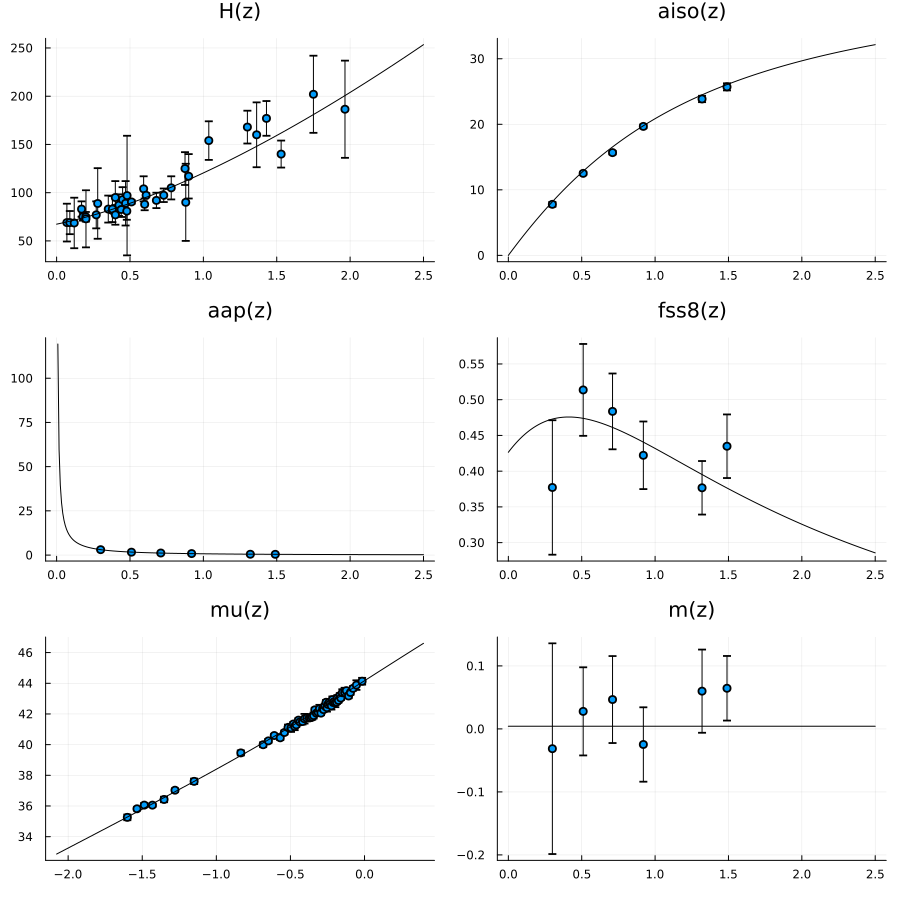

In [13]:
p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,title="H(z)", legend=false)
p1 = plot(dataDESI.z1, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,title="aiso(z)", legend=false)
p2 = plot(dataDESI.z1, dataDESI.data_dhdm, yerr=aap_err, seriestype=:scatter, title="aap(z)", legend=false)
p3 = plot(dataDESI.z1, dataDESI.data_fss8, yerr=fss8_err, seriestype=:scatter, title="fss8(z)", legend=false)
p4 = plot(log10.(datamu.z), datamu.data, yerr=mu_err, seriestype=:scatter, title="mu(z)", legend=false)
# p5 = plot(dataCMB.z, dataCMB.data, yerr=CMB_err, seriestype=:scatter, title="CMB", legend=false)
p6 = plot(dataDESI.z1, dataDESI.data_m, yerr=m_err, seriestype=:scatter, title="m(z)", legend=false)

plot!(p0, z_integ1, hz_from_ez(z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p1, z_integ1, a_iso(z_integ1, cosmo_fid.cpar.h, r_d_fid, ez_fid_test), color=:black)
plot!(p2, z_integ1, a_ap(z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p3, z_integ1, fss8_from_ez(z_integ1, z_integ1, ez_fid_test, k_integ, r_d_fid, r_d_fid, cosmo_fid), color=:black)
plot!(p4, log10.(z_integ1), mu(z_integ1, z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
# plot!(p5, z_CMB[990:end], theta2(z_CMB, r_star, cosmo_fid.cpar.h, ez_CMB_test)[990:end], color=:black)
plot!(p6, z_integ1, fill(m_shapefit2(cosmo, Tk_EH_fid, k_integ, 0.03), length(z_integ1)), color=:black)

plot(p0, p1, p2, p3, p4, p6, layout=(3,2), size=(900,900))

In [ ]:
# data_obs = [datahz.data; datatracerfs8.data; dataDESI.data];
# z_obs = [datahz.z; datatracerfs8.z; dataDESI.z];
# covariance_obs = BlockDiagonal([datahz.cov, datatracerfs8.cov, dataDESI.cov]);
data_obs = [datahz.data; datatracerfs8.data; dataDESI.data; datamu.data];
z_obs = [datahz.z; datatracerfs8.z; dataDESI.z; datamu.z];
covariance_obs = BlockDiagonal([datahz.cov, datatracerfs8.cov, dataDESI.cov, datamu.cov]);

In [ ]:
cov_df = DataFrame(covariance_obs, :auto)
CSV.write("covariance_data.csv", cov_df)